In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# load the dataset and add headers
df = pd.read_csv(
    "data/ex2data1.txt",
    header=None,
    names=["Exam1", "Exam2", "Admitted"]
)

df.head()

,Exam1,Exam2,Admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [6]:
df.shape

(100, 3)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam1     100 non-null    float64
 1   Exam2     100 non-null    float64
 2   Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [5]:
df.describe()

,Exam1,Exam2,Admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


In [ ]:
# separate admitted vs not-admitted individuals
admitted = df[df["Admitted"] == 1]
not_admitted = df[df["Admitted"] == 0]

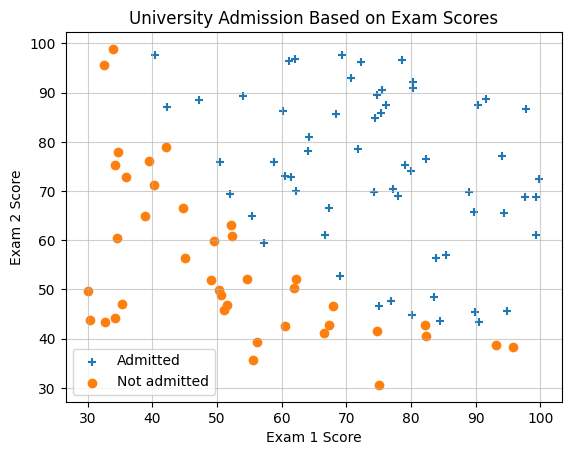

In [12]:
# plot the scatter plot of admitted and not-admitted individuals
plt.scatter(admitted["Exam1"], admitted["Exam2"], marker="+", label="Admitted")
plt.scatter(not_admitted["Exam1"], not_admitted["Exam2"], marker="o", label="Not admitted")

plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.legend()
plt.grid(alpha=0.6)
plt.title("University Admission Based on Exam Scores")

plt.show()

**Observation**: the data seems to be divided roughly along the secondary diagonal, with admitted students on the second half of the plane defined by this diagonal. Note that having one low score does not disqualify a candidate, as long as the second score is sufficiently high.

In [ ]:
# Separate dependent and independent variables
X = df[["Exam1", "Exam2"]]
y = df["Admitted"]

# Split the dataset into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Obtain predicted output by the model with test input
y_pred = model.predict(X_test)
# Calculate accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8


In [ ]:
# Get metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.88      0.78         8
           1       0.90      0.75      0.82        12

    accuracy                           0.80        20
   macro avg       0.80      0.81      0.80        20
weighted avg       0.82      0.80      0.80        20



**Observation**: The logistic regression model achieved an accuracy of 80% on the test dataset. The model performs well in predicting admitted students, with a precision of 0.90, meaning most predicted admissions are correct. However, the recall for admitted students is lower (0.75), indicating that some admitted students are incorrectly classified as not admitted. Overall, the results suggest that exam scores are a good predictor of admission, and logistic regression provides a reasonably accurate classification model.